core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 4 completed the race distance 00:00.022000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '63', '12', '2

Index(['Date', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake', 'DRS', 'Source',
       'Time', 'SessionTime', 'Distance'],
      dtype='object')


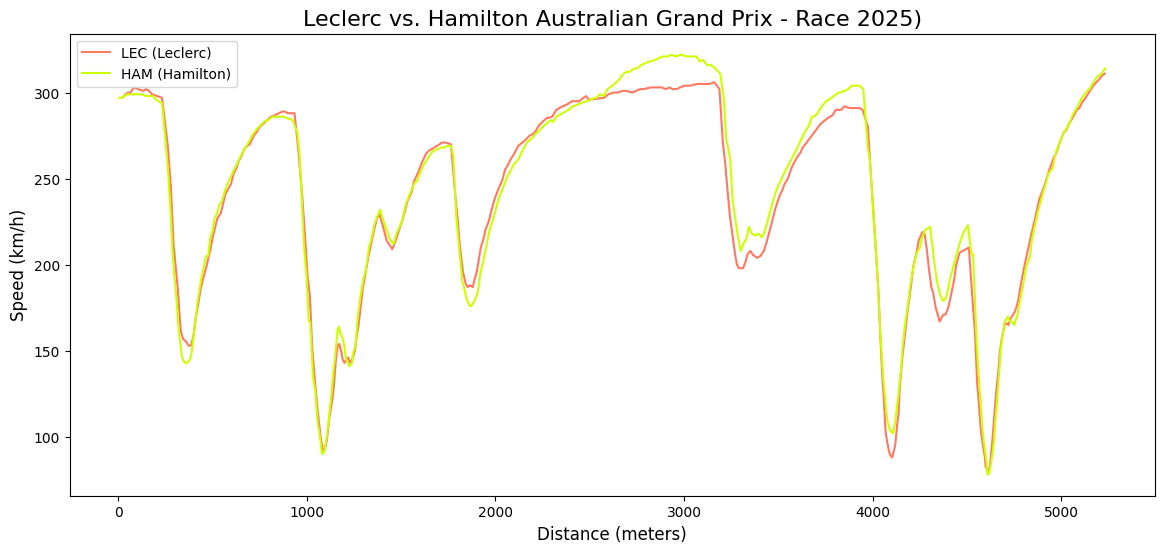

In [6]:
import fastf1
import fastf1.plotting
import matplotlib.pyplot as plt

# use the downloaded data from the data/raw folder
fastf1.Cache.enable_cache('../data/raw')

# fastf1.plotting.setup_mpl(mpl_timedelta_support=True, color_scheme=fastf1)
fastf1.plotting.setup_mpl(mpl_timedelta_support=True)

# load one of the races
session = fastf1.get_session(2025, 1, 'R')
session.load()

# get the fastest lap
fastest_lap = session.laps.pick_fastest()

# get the telemetry from that lap
telemetry = fastest_lap.get_car_data().add_distance()
print(telemetry.columns)

# pick fastest lap from both ferrari drivers
lap_lec = session.laps.pick_drivers('LEC').pick_fastest()
lap_ham = session.laps.pick_drivers('HAM').pick_fastest()

# get the car telemetry
tel_lec = lap_lec.get_car_data().add_distance()
tel_ham = lap_ham.get_car_data().add_distance()

fig, ax = plt.subplots(figsize=(14, 6))

# plot leclerc
ax.plot(tel_lec['Distance'], tel_lec['Speed'], 
        color="#FF26009E", label='LEC (Leclerc)')

# plot hamilton
ax.plot(tel_ham['Distance'], tel_ham['Speed'], 
        color='#CCFF00', label='HAM (Hamilton)')

ax.set_xlabel('Distance (meters)', fontsize=12)
ax.set_ylabel('Speed (km/h)', fontsize=12)
ax.set_title(f"Leclerc vs. Hamilton {session.event.EventName} - {session.name} 2025)", fontsize=16)
ax.legend()

plt.show()